In [4]:
import requests

BASE_URL = "https://api.jolpi.ca/ergast/f1"
START_YEAR = 1980
END_YEAR = 2025

def check_f1_headers(year):
    # Consultamos el calendario de carreras de un año específico
    url = f"{BASE_URL}/{year}.json"

    try:
        response = requests.get(url)
        response.raise_for_status() # Lanza error si la petición falla
        data = response.json()

        # Navegamos en el JSON para encontrar la lista de carreras
        # La estructura típica es: MRData -> RaceTable -> Races
        mr_data = data.get("MRData", {})
        race_table = mr_data.get("RaceTable", {})
        races = race_table.get("Races", [])

        if races:
            print(f"--- Encabezados detectados para el año {year} ---")
            # Obtenemos las llaves del primer elemento de la lista de carreras
            headers = races[0].keys()
            for header in headers:
                print(f"- {header}")
        else:
            print(f"No se encontraron datos de carreras para el año {year}.")

    except requests.exceptions.RequestException as e:
        print(f"Error al conectar con la API: {e}")

# Ejemplo: Revisamos el primer año del rango
check_f1_headers(START_YEAR)

--- Encabezados detectados para el año 1980 ---
- season
- round
- url
- raceName
- Circuit
- date


In [5]:
import requests
import pandas as pd # Usamos pandas para que sea vea como una tabla limpia

BASE_URL = "https://api.jolpi.ca/ergast/f1"
START_YEAR = 1980
END_YEAR = 2024  # Nota: 2025 aún no tiene resultados completos de todas las carreras

def get_winners_by_year(year):
    # La ruta '/results/1' nos da solo al ganador de cada carrera de ese año
    url = f"{BASE_URL}/{year}/results/1.json"

    try:
        response = requests.get(url)
        data = response.json()
        races = data.get("MRData", {}).get("RaceTable", {}).get("Races", [])

        results_list = []

        for race in races:
            # Extraemos la info específica del ganador
            result = race["Results"][0]
            driver = f"{result['Driver']['givenName']} {result['Driver']['familyName']}"
            constructor = result['Constructor']['name']

            results_list.append({
                "Año": race["season"],
                "GP": race["raceName"],
                "Ganador": driver,
                "Escudería": constructor,
                "Fecha": race["date"]
            })

        return results_list

    except Exception as e:
        print(f"Error en {year}: {e}")
        return []

# --- Ejecución ---
all_winners = []
# Probemos con un rango corto (ej. 2023-2024) para no saturar la API rápido
for year in range(2023, 2025):
    print(f"Consultando año {year}...")
    all_winners.extend(get_winners_by_year(year))

# Convertimos a DataFrame para verlo bonito
df = pd.DataFrame(all_winners)
print("\n--- RESUMEN DE GANADORES ---")
print(df.head(10))

Consultando año 2023...
Consultando año 2024...

--- RESUMEN DE GANADORES ---
    Año                        GP         Ganador Escudería       Fecha
0  2023        Bahrain Grand Prix  Max Verstappen  Red Bull  2023-03-05
1  2023  Saudi Arabian Grand Prix    Sergio Pérez  Red Bull  2023-03-19
2  2023     Australian Grand Prix  Max Verstappen  Red Bull  2023-04-02
3  2023     Azerbaijan Grand Prix    Sergio Pérez  Red Bull  2023-04-30
4  2023          Miami Grand Prix  Max Verstappen  Red Bull  2023-05-07
5  2023         Monaco Grand Prix  Max Verstappen  Red Bull  2023-05-28
6  2023        Spanish Grand Prix  Max Verstappen  Red Bull  2023-06-04
7  2023       Canadian Grand Prix  Max Verstappen  Red Bull  2023-06-18
8  2023       Austrian Grand Prix  Max Verstappen  Red Bull  2023-07-02
9  2023        British Grand Prix  Max Verstappen  Red Bull  2023-07-09


In [3]:
# -*- coding: utf-8 -*-

import json
import time
import random
from pathlib import Path

import requests
import pandas as pd

BASE = "https://api.jolpi.ca/ergast/f1"
START_YEAR = 1980
END_YEAR = 2025

OUT_DIR = Path("eda_output")
OUT_DIR.mkdir(exist_ok=True)


def fetch_json(url: str, retries: int = 6, timeout: int = 25):
    for attempt in range(retries):
        try:
            r = requests.get(url, timeout=timeout)

            if r.status_code == 429:
                wait = 2 + attempt * 2 + random.random()
                print(f"429 en {url} | esperando {wait:.1f}s...")
                time.sleep(wait)
                continue

            r.raise_for_status()
            return r.json()

        except requests.RequestException as e:
            wait = 1 + attempt + random.random()
            print(f"Error en {url}: {e} | reintento en {wait:.1f}s")
            time.sleep(wait)

    raise RuntimeError(f"No se pudo obtener respuesta de: {url}")


def safe_int(value, default=0):
    try:
        return int(value)
    except (TypeError, ValueError):
        return default


def safe_float(value, default=0.0):
    try:
        return float(value)
    except (TypeError, ValueError):
        return default


def get_constructor_standings(year: int) -> pd.DataFrame:
    """Clasificación final de constructores."""
    url = f"{BASE}/{year}/constructorStandings.json"
    data = fetch_json(url)

    lists_ = data.get("MRData", {}).get("StandingsTable", {}).get("StandingsLists", [])
    if not lists_:
        return pd.DataFrame()

    standings = lists_[0].get("ConstructorStandings", [])
    rows = []

    for row in standings:
        constructor = row.get("Constructor", {})
        rows.append({
            "year": year,
            "position": safe_int(row.get("position", row.get("positionText", 0))),
            "constructor": constructor.get("name"),
            "constructor_id": constructor.get("constructorId"),
            "points": safe_float(row.get("points")),
            "wins": safe_int(row.get("wins"))
        })

    return pd.DataFrame(rows)


def get_driver_champion(year: int) -> dict:
    """Campeón de pilotos."""
    url = f"{BASE}/{year}/driverStandings/1.json"
    data = fetch_json(url)

    lists_ = data.get("MRData", {}).get("StandingsTable", {}).get("StandingsLists", [])
    if not lists_:
        return {}

    standings = lists_[0].get("DriverStandings", [])
    if not standings:
        return {}

    row = standings[0]
    d = row.get("Driver", {})

    return {
        "year": year,
        "driverChampion": f'{d.get("givenName", "")} {d.get("familyName", "")}'.strip(),
        "driverChampionId": d.get("driverId"),
        "driverNationality": d.get("nationality"),
        "driverPoints": safe_float(row.get("points")),
        "driverWins": safe_int(row.get("wins"))
    }


def get_races(year: int) -> pd.DataFrame:
    """Calendario de carreras."""
    url = f"{BASE}/{year}.json"
    data = fetch_json(url)

    races = data.get("MRData", {}).get("RaceTable", {}).get("Races", [])
    rows = []

    for r in races:
        circuit = r.get("Circuit", {})
        location = circuit.get("Location", {})
        rows.append({
            "year": year,
            "round": safe_int(r.get("round")),
            "raceName": r.get("raceName"),
            "date": r.get("date"),
            "circuitId": circuit.get("circuitId"),
            "circuitName": circuit.get("circuitName"),
            "locality": location.get("locality"),
            "country": location.get("country")
        })

    return pd.DataFrame(rows)


def get_winners(year: int) -> pd.DataFrame:
    """Ganador de cada carrera."""
    url = f"{BASE}/{year}/results/1.json?limit=100"
    data = fetch_json(url)

    races = data.get("MRData", {}).get("RaceTable", {}).get("Races", [])
    rows = []

    for race in races:
        results = race.get("Results", [])
        if not results:
            continue

        winner = results[0]
        driver = winner.get("Driver", {})
        constructor = winner.get("Constructor", {})

        rows.append({
            "year": year,
            "round": safe_int(race.get("round")),
            "raceName": race.get("raceName"),
            "date": race.get("date"),
            "winnerDriver": f'{driver.get("givenName", "")} {driver.get("familyName", "")}'.strip(),
            "winnerDriverId": driver.get("driverId"),
            "winnerConstructor": constructor.get("name"),
            "winnerConstructorId": constructor.get("constructorId")
        })

    return pd.DataFrame(rows)


def build_raw_data(start_year: int = START_YEAR, end_year: int = END_YEAR):
    all_constructor_standings = []
    all_driver_champions = []
    all_races = []
    all_winners = []

    for year in range(start_year, end_year + 1):
        print(f"Procesando {year}...")

        try:
            df_const = get_constructor_standings(year)
            time.sleep(0.25 + random.random() * 0.20)

            driver_champ = get_driver_champion(year)
            time.sleep(0.25 + random.random() * 0.20)

            df_races = get_races(year)
            time.sleep(0.25 + random.random() * 0.20)

            df_winners = get_winners(year)
            time.sleep(0.25 + random.random() * 0.20)

            if not df_const.empty:
                all_constructor_standings.append(df_const)

            if driver_champ:
                all_driver_champions.append(driver_champ)

            if not df_races.empty:
                all_races.append(df_races)

            if not df_winners.empty:
                all_winners.append(df_winners)

        except Exception as e:
            print(f"Error procesando {year}: {e}")

    constructor_standings = pd.concat(all_constructor_standings, ignore_index=True) if all_constructor_standings else pd.DataFrame()
    driver_champions = pd.DataFrame(all_driver_champions)
    races = pd.concat(all_races, ignore_index=True) if all_races else pd.DataFrame()
    winners = pd.concat(all_winners, ignore_index=True) if all_winners else pd.DataFrame()

    return constructor_standings, driver_champions, races, winners


def build_season_summary(
    constructor_standings: pd.DataFrame,
    driver_champions: pd.DataFrame,
    races: pd.DataFrame,
    winners: pd.DataFrame
) -> pd.DataFrame:
    """Tabla agregada por temporada."""

    top2 = (
        constructor_standings[constructor_standings["position"].isin([1, 2])]
        .copy()
        .sort_values(["year", "position"])
    )

    top1 = (
        top2[top2["position"] == 1][["year", "constructor", "points", "wins"]]
        .rename(columns={
            "constructor": "constructorChampion",
            "points": "champPoints",
            "wins": "teamWins"
        })
    )

    top2_only = (
        top2[top2["position"] == 2][["year", "constructor", "points"]]
        .rename(columns={
            "constructor": "p2Constructor",
            "points": "p2Points"
        })
    )

    races_per_season = (
        races.groupby("year", as_index=False)
        .agg(
            racesInSeason=("round", "count"),
            circuitsUsed=("circuitId", "nunique"),
            countriesVisited=("country", "nunique")
        )
    )

    unique_winners = (
        winners.groupby("year", as_index=False)
        .agg(
            uniqueWinningConstructors=("winnerConstructor", "nunique"),
            uniqueWinningDrivers=("winnerDriver", "nunique")
        )
    )

    season_summary = (
        top1
        .merge(top2_only, on="year", how="left")
        .merge(driver_champions, on="year", how="left")
        .merge(races_per_season, on="year", how="left")
        .merge(unique_winners, on="year", how="left")
    )

    season_summary["pointsGap"] = season_summary["champPoints"] - season_summary["p2Points"]
    season_summary["dominance"] = season_summary["teamWins"] / season_summary["racesInSeason"]
    season_summary["title"] = "Temporada " + season_summary["year"].astype(str)

    season_summary = season_summary.sort_values("year").reset_index(drop=True)
    return season_summary


def save_outputs(
    constructor_standings: pd.DataFrame,
    driver_champions: pd.DataFrame,
    races: pd.DataFrame,
    winners: pd.DataFrame,
    season_summary: pd.DataFrame
):
    constructor_standings.to_csv(OUT_DIR / "constructor_standings.csv", index=False, encoding="utf-8-sig")
    driver_champions.to_csv(OUT_DIR / "driver_champions.csv", index=False, encoding="utf-8-sig")
    races.to_csv(OUT_DIR / "races.csv", index=False, encoding="utf-8-sig")
    winners.to_csv(OUT_DIR / "race_winners.csv", index=False, encoding="utf-8-sig")
    season_summary.to_csv(OUT_DIR / "season_summary.csv", index=False, encoding="utf-8-sig")


def print_basic_eda(
    constructor_standings: pd.DataFrame,
    driver_champions: pd.DataFrame,
    races: pd.DataFrame,
    winners: pd.DataFrame,
    season_summary: pd.DataFrame
):
    print("\n" + "=" * 80)
    print("EDA BÁSICO")
    print("=" * 80)

    datasets = {
        "constructor_standings": constructor_standings,
        "driver_champions": driver_champions,
        "races": races,
        "winners": winners,
        "season_summary": season_summary
    }

    for name, df in datasets.items():
        print(f"\n--- {name.upper()} ---")
        print(f"shape: {df.shape}")
        print("columns:", list(df.columns))
        print("\nhead:")
        print(df.head(3))
        print("\nmissing values:")
        print(df.isna().sum())

    print("\n" + "=" * 80)
    print("INSIGHTS EXPLORATORIOS")
    print("=" * 80)

    print("\nTemporadas con mayor dominancia:")
    print(
        season_summary[["year", "constructorChampion", "dominance"]]
        .sort_values("dominance", ascending=False)
        .head(10)
        .to_string(index=False)
    )

    print("\nTemporadas más cerradas por diferencia de puntos:")
    print(
        season_summary[["year", "constructorChampion", "p2Constructor", "pointsGap"]]
        .sort_values("pointsGap", ascending=True)
        .head(10)
        .to_string(index=False)
    )

    print("\nTemporadas con más constructores ganadores:")
    print(
        season_summary[["year", "uniqueWinningConstructors"]]
        .sort_values("uniqueWinningConstructors", ascending=False)
        .head(10)
        .to_string(index=False)
    )

    print("\nResumen descriptivo de métricas numéricas:")
    num_cols = [
        "champPoints", "teamWins", "p2Points", "pointsGap",
        "racesInSeason", "uniqueWinningConstructors",
        "uniqueWinningDrivers", "dominance"
    ]
    print(season_summary[num_cols].describe().round(3).to_string())


def generate_markdown_report(
    constructor_standings: pd.DataFrame,
    driver_champions: pd.DataFrame,
    races: pd.DataFrame,
    winners: pd.DataFrame,
    season_summary: pd.DataFrame
):
    report = []

    report.append("# Exploración inicial de la base de datos de Fórmula 1\n")
    report.append("## 1. Fuente\n")
    report.append(
        "Los datos fueron consultados desde la API pública de Ergast/Jolpica para acceder a resultados históricos de Fórmula 1.\n"
    )

    report.append("## 2. Recursos explorados\n")
    report.append("- Constructor Standings\n")
    report.append("- Driver Standings\n")
    report.append("- Races\n")
    report.append("- Results (ganadores por carrera)\n")

    report.append("## 3. Tablas construidas en la exploración\n")
    report.append(f"- constructor_standings: {constructor_standings.shape[0]} filas, {constructor_standings.shape[1]} columnas\n")
    report.append(f"- driver_champions: {driver_champions.shape[0]} filas, {driver_champions.shape[1]} columnas\n")
    report.append(f"- races: {races.shape[0]} filas, {races.shape[1]} columnas\n")
    report.append(f"- winners: {winners.shape[0]} filas, {winners.shape[1]} columnas\n")
    report.append(f"- season_summary: {season_summary.shape[0]} filas, {season_summary.shape[1]} columnas\n")

    report.append("## 4. Variables seleccionadas para el modelado\n")
    report.append(
        "Se seleccionaron variables por temporada como `constructorChampion`, `driverChampion`, "
        "`champPoints`, `teamWins`, `racesInSeason`, `p2Constructor`, `p2Points`, "
        "`pointsGap`, `uniqueWinningConstructors` y `dominance`.\n"
    )

    report.append("## 5. Métricas derivadas\n")
    report.append("- `dominance`: porcentaje de victorias del constructor campeón\n")
    report.append("- `pointsGap`: diferencia de puntos entre el primer y segundo constructor\n")
    report.append("- `uniqueWinningConstructors`: cantidad de equipos ganadores por temporada\n")

    top_dom = (
        season_summary[["year", "constructorChampion", "dominance"]]
        .sort_values("dominance", ascending=False)
        .head(5)
    )

    report.append("## 6. Temporadas con mayor dominancia\n")
    report.append(top_dom.to_markdown(index=False))
    report.append("\n")

    closest = (
        season_summary[["year", "constructorChampion", "p2Constructor", "pointsGap"]]
        .sort_values("pointsGap", ascending=True)
        .head(5)
    )

    report.append("## 7. Temporadas más cerradas\n")
    report.append(closest.to_markdown(index=False))
    report.append("\n")

    with open(OUT_DIR / "eda_report.md", "w", encoding="utf-8") as f:
        f.write("\n".join(report))


def main():
    constructor_standings, driver_champions, races, winners = build_raw_data(
        START_YEAR, END_YEAR
    )

    season_summary = build_season_summary(
        constructor_standings, driver_champions, races, winners
    )

    save_outputs(
        constructor_standings, driver_champions, races, winners, season_summary
    )

    print_basic_eda(
        constructor_standings, driver_champions, races, winners, season_summary
    )

    generate_markdown_report(
        constructor_standings, driver_champions, races, winners, season_summary
    )

    print("\nArchivos generados en:", OUT_DIR.resolve())
    print("- constructor_standings.csv")
    print("- driver_champions.csv")
    print("- races.csv")
    print("- race_winners.csv")
    print("- season_summary.csv")
    print("- eda_report.md")


if __name__ == "__main__":
    main()



Procesando 1980...
Procesando 1981...
Procesando 1982...
Procesando 1983...
Procesando 1984...
Procesando 1985...
Procesando 1986...
Procesando 1987...
Procesando 1988...
Procesando 1989...
Procesando 1990...
Procesando 1991...
Procesando 1992...
Procesando 1993...
Procesando 1994...
Procesando 1995...
Procesando 1996...
Procesando 1997...
Procesando 1998...
Procesando 1999...
Procesando 2000...
Procesando 2001...
Procesando 2002...
Procesando 2003...
Procesando 2004...
429 en https://api.jolpi.ca/ergast/f1/2004.json | esperando 2.9s...
Procesando 2005...
429 en https://api.jolpi.ca/ergast/f1/2005/constructorStandings.json | esperando 2.9s...
429 en https://api.jolpi.ca/ergast/f1/2005.json | esperando 2.7s...
Procesando 2006...
429 en https://api.jolpi.ca/ergast/f1/2006/constructorStandings.json | esperando 2.7s...
429 en https://api.jolpi.ca/ergast/f1/2006/driverStandings/1.json | esperando 2.1s...
429 en https://api.jolpi.ca/ergast/f1/2006/results/1.json?limit=100 | esperando 2.5s...

In [6]:
!zip -r eda_output.zip /content/eda_output

  adding: content/eda_output/ (stored 0%)
  adding: content/eda_output/race_winners.csv (deflated 87%)
  adding: content/eda_output/races.csv (deflated 87%)
  adding: content/eda_output/season_summary.csv (deflated 68%)
  adding: content/eda_output/driver_champions.csv (deflated 68%)
  adding: content/eda_output/eda_report.md (deflated 62%)
  adding: content/eda_output/constructor_standings.csv (deflated 79%)


In [7]:
from google.colab import files
files.download('eda_output.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import pandas as pd

df = pd.read_csv("/content/eda_output/season_summary.csv")

df.head()

,year,constructorChampion,champPoints,teamWins,p2Constructor,p2Points,driverChampion,driverChampionId,driverNationality,driverPoints,driverWins,racesInSeason,circuitsUsed,countriesVisited,uniqueWinningConstructors,uniqueWinningDrivers,pointsGap,dominance,title
0,1980,Williams,120.0,6,Ligier,66.0,Alan Jones,jones,Australian,67.0,5,14,14,13,4,7,54.0,0.428571,Temporada 1980
1,1981,Williams,95.0,4,Brabham,61.0,Nelson Piquet,piquet,Brazilian,50.0,3,15,15,13,6,7,34.0,0.266667,Temporada 1981
2,1982,Ferrari,74.0,3,McLaren,69.0,Keke Rosberg,keke_rosberg,Finnish,44.0,1,16,16,12,7,11,5.0,0.187500,Temporada 1982
3,1983,Ferrari,89.0,4,Renault,79.0,Nelson Piquet,piquet,Brazilian,59.0,3,15,15,12,6,8,10.0,0.266667,Temporada 1983
4,1984,McLaren,143.5,12,Ferrari,57.5,Niki Lauda,lauda,Austrian,72.0,5,16,16,13,4,5,86.0,0.750000,Temporada 1984


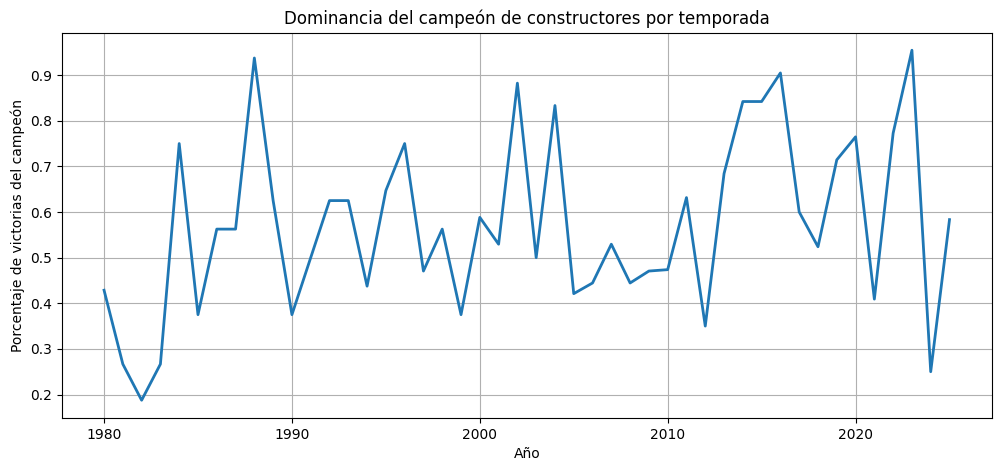

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df["year"], df["dominance"], linewidth=2)

plt.title("Dominancia del campeón de constructores por temporada")
plt.xlabel("Año")
plt.ylabel("Porcentaje de victorias del campeón")

plt.grid(True)

plt.show()

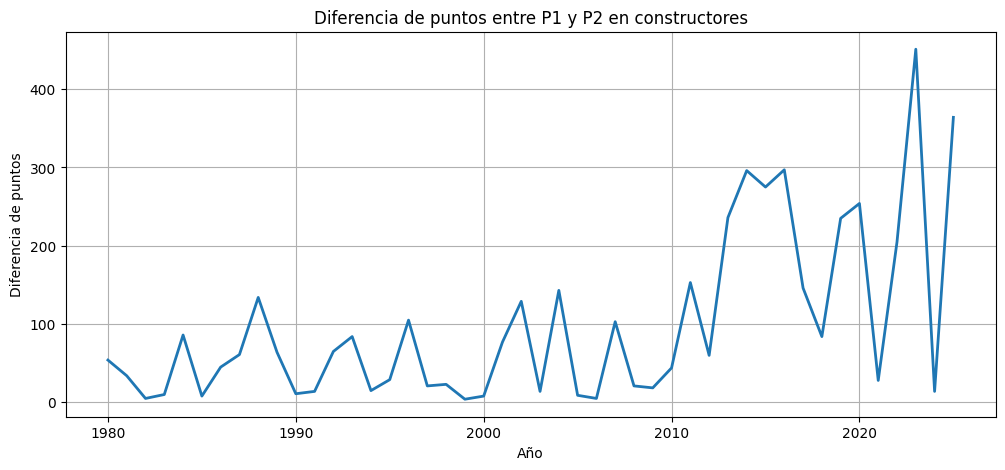

In [14]:
plt.figure(figsize=(12,5))

plt.plot(df["year"], df["pointsGap"], linewidth=2)

plt.title("Diferencia de puntos entre P1 y P2 en constructores")
plt.xlabel("Año")
plt.ylabel("Diferencia de puntos")

plt.grid(True)

plt.show()

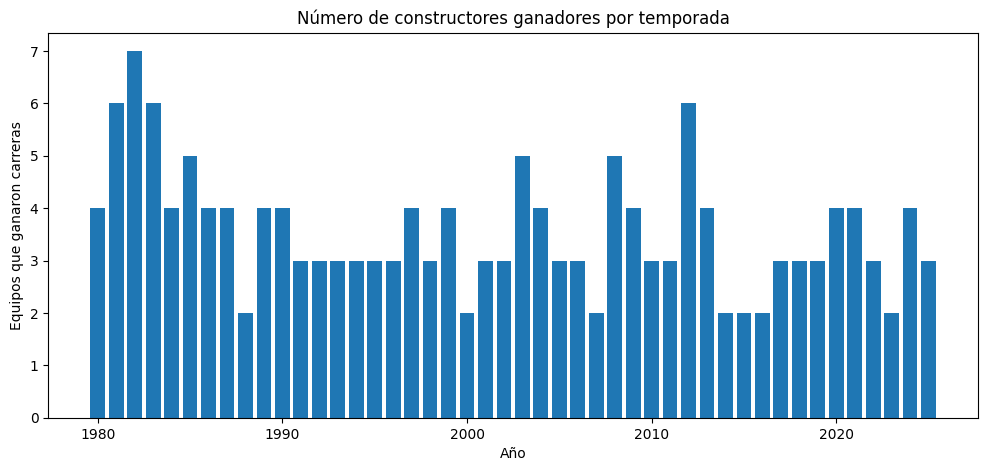

In [15]:
plt.figure(figsize=(12,5))

plt.bar(df["year"], df["uniqueWinningConstructors"])

plt.title("Número de constructores ganadores por temporada")
plt.xlabel("Año")
plt.ylabel("Equipos que ganaron carreras")

plt.show()